# 🪖 Helmet vs No-Helmet Image Classification
## CNN + Transfer Learning | Grad-CAM | ROC Curves | Full Evaluation

**Dataset:** [PROJECT 01 – Roboflow Universe](https://universe.roboflow.com/project-xvwed/project-01-mj51m/dataset/1)  
**Task:** Binary Image Classification (Helmet / No Helmet)  
**Images:** 2,886 total (Train: 2020 | Valid: 577 | Test: 289)

---
### Pipeline Overview
1. Dataset download & loading
2. Preprocessing – resize, normalize
3. Train / Validation / Test split
4. Data augmentation
5. Custom CNN model
6. Transfer learning (MobileNetV2 + ResNet50)
7. Training & evaluation
8. Confusion matrix, classification report
9. Accuracy / Loss curves
10. ROC curves
11. Grad-CAM visualisations
12. Model comparison table
13. Error analysis


---
## Research Questions

This project is guided by the following research questions:

**RQ1. Baseline Performance**  
What classification accuracy can a custom-designed CNN achieve on the Helmet / No-Helmet dataset without leveraging any pre-trained features?

**RQ2. Transfer Learning Advantage**  
To what extent do deep pre-trained architectures (MobileNetV2 and ResNet50) outperform a custom CNN in terms of accuracy, F1-score, and AUC when fine-tuned on a relatively small safety-helmet dataset?

**RQ3. Model Interpretability**  
Which image regions does the best-performing model attend to when classifying helmet usage, as revealed by Grad-CAM visualisations, and are these regions semantically meaningful (e.g., head/helmet area)?

**RQ4. Data Augmentation Impact**  
How does applying standard augmentation techniques (random flips, rotations, zoom, brightness shifts) affect generalisation and reduce over-fitting compared to training without augmentation?

**RQ5. Error Characterisation**  
What are the dominant failure modes of each model (false positives vs. false negatives), and what visual or contextual factors contribute to misclassifications?

---


## 1. Install & Import Dependencies

In [1]:
# Install Roboflow SDK to download the dataset
!pip install roboflow -q

import os, random, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Detect GPU
print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# Directory for saving figures
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path('saved_models')
MODELS_DIR.mkdir(exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 5.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 32.9 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.9 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


2026-06-07 21:02:42.661213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780866162.853470      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780866162.913398      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780866163.367325      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780866163.367360      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780866163.367363      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Download Dataset from Roboflow

In [15]:
from pathlib import Path

DATASET_PATH = Path("/kaggle/input/datasets/nikhilsaiprabhath/safety-helmet-dataset")

TRAIN_DIR = DATASET_PATH / "train"
VALID_DIR = DATASET_PATH / "valid"
TEST_DIR = DATASET_PATH / "test"

## 3. Explore the Dataset

Classes: ['Helmet', 'No Helmet']
Train  → {'Helmet': 975, 'No Helmet': 1045}  (total: 2020)
Valid  → {'Helmet': 283, 'No Helmet': 294}  (total: 577)
Test   → {'Helmet': 134, 'No Helmet': 155}  (total: 289)


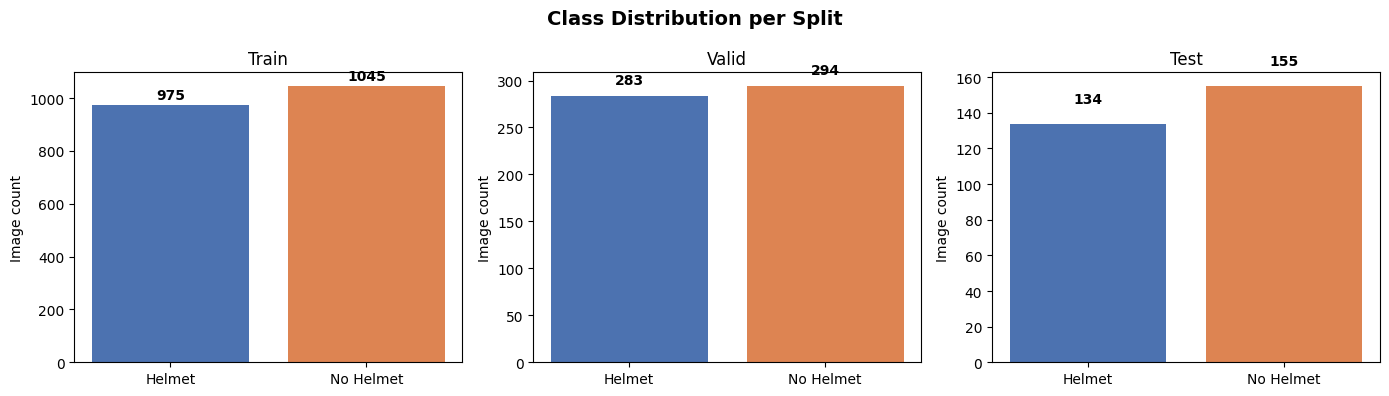

Saved: 01_class_distribution.pdf


In [16]:
# ── Count images per class per split ──────────────────────────
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print("Classes:", CLASS_NAMES)

def count_images(split_dir):
    return {cls: len(list((split_dir / cls).glob('*.*')))
            for cls in CLASS_NAMES}

counts = {
    'Train': count_images(TRAIN_DIR),
    'Valid': count_images(VALID_DIR),
    'Test' : count_images(TEST_DIR),
}

for split, c in counts.items():
    print(f"{split:6s} → {c}  (total: {sum(c.values())})")

# ── Bar chart of class distribution ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class Distribution per Split', fontsize=14, fontweight='bold')
colors = ['#4C72B0', '#DD8452']

for ax, (split, c) in zip(axes, counts.items()):
    bars = ax.bar(c.keys(), c.values(), color=colors)
    ax.set_title(split)
    ax.set_ylabel('Image count')
    for bar, val in zip(bars, c.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_class_distribution.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_class_distribution.pdf")


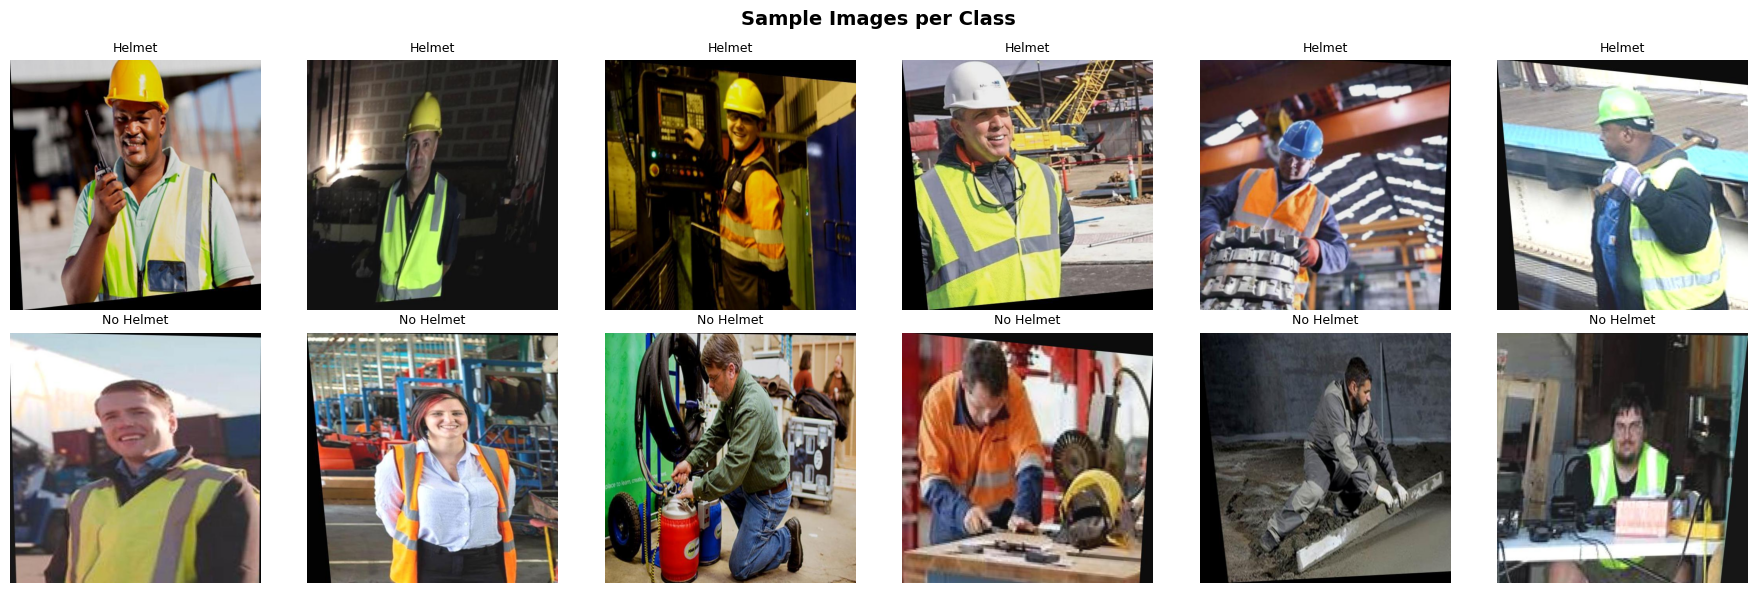

Saved: 02_sample_images.pdf


In [17]:
# ── Visualise sample images from each class ───────────────────
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    imgs = list((TRAIN_DIR / cls).glob('*.*'))[:6]
    for col, img_path in enumerate(imgs):
        img = plt.imread(str(img_path))
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_sample_images.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_sample_images.pdf")


## 4. Preprocessing – Resize, Normalise, Augment

In [18]:
# ── Hyperparameters ────────────────────────────────────────────
IMG_SIZE    = 224          # Standard input size for MobileNetV2 / ResNet50
BATCH_SIZE  = 32
EPOCHS_CNN  = 30           # Custom CNN epochs
EPOCHS_TL   = 20           # Transfer-learning epochs (fine-tune)
LEARN_RATE  = 1e-3
NUM_CLASSES = len(CLASS_NAMES)

print(f"Image size  : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Classes     : {CLASS_NAMES}")

# ── Augmentation for training ──────────────────────────────────
# All pixel values are rescaled to [0, 1].
# Augmentations add robustness: flips, rotations, zoom, shear, brightness.
train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,
    rotation_range    = 20,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.1,
    zoom_range        = 0.15,
    horizontal_flip   = True,
    brightness_range  = [0.8, 1.2],
    fill_mode         = 'nearest'
)

# Validation & test only rescale – no augmentation
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

# ── Create generators ─────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' if NUM_CLASSES == 2 else 'categorical',
    seed=42, shuffle=True
)

valid_gen = eval_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' if NUM_CLASSES == 2 else 'categorical',
    seed=42, shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' if NUM_CLASSES == 2 else 'categorical',
    seed=42, shuffle=False
)

print("\nClass indices:", train_gen.class_indices)


Image size  : 224x224
Batch size  : 32
Classes     : ['Helmet', 'No Helmet']
Found 2020 images belonging to 2 classes.
Found 577 images belonging to 2 classes.
Found 289 images belonging to 2 classes.

Class indices: {'Helmet': 0, 'No Helmet': 1}


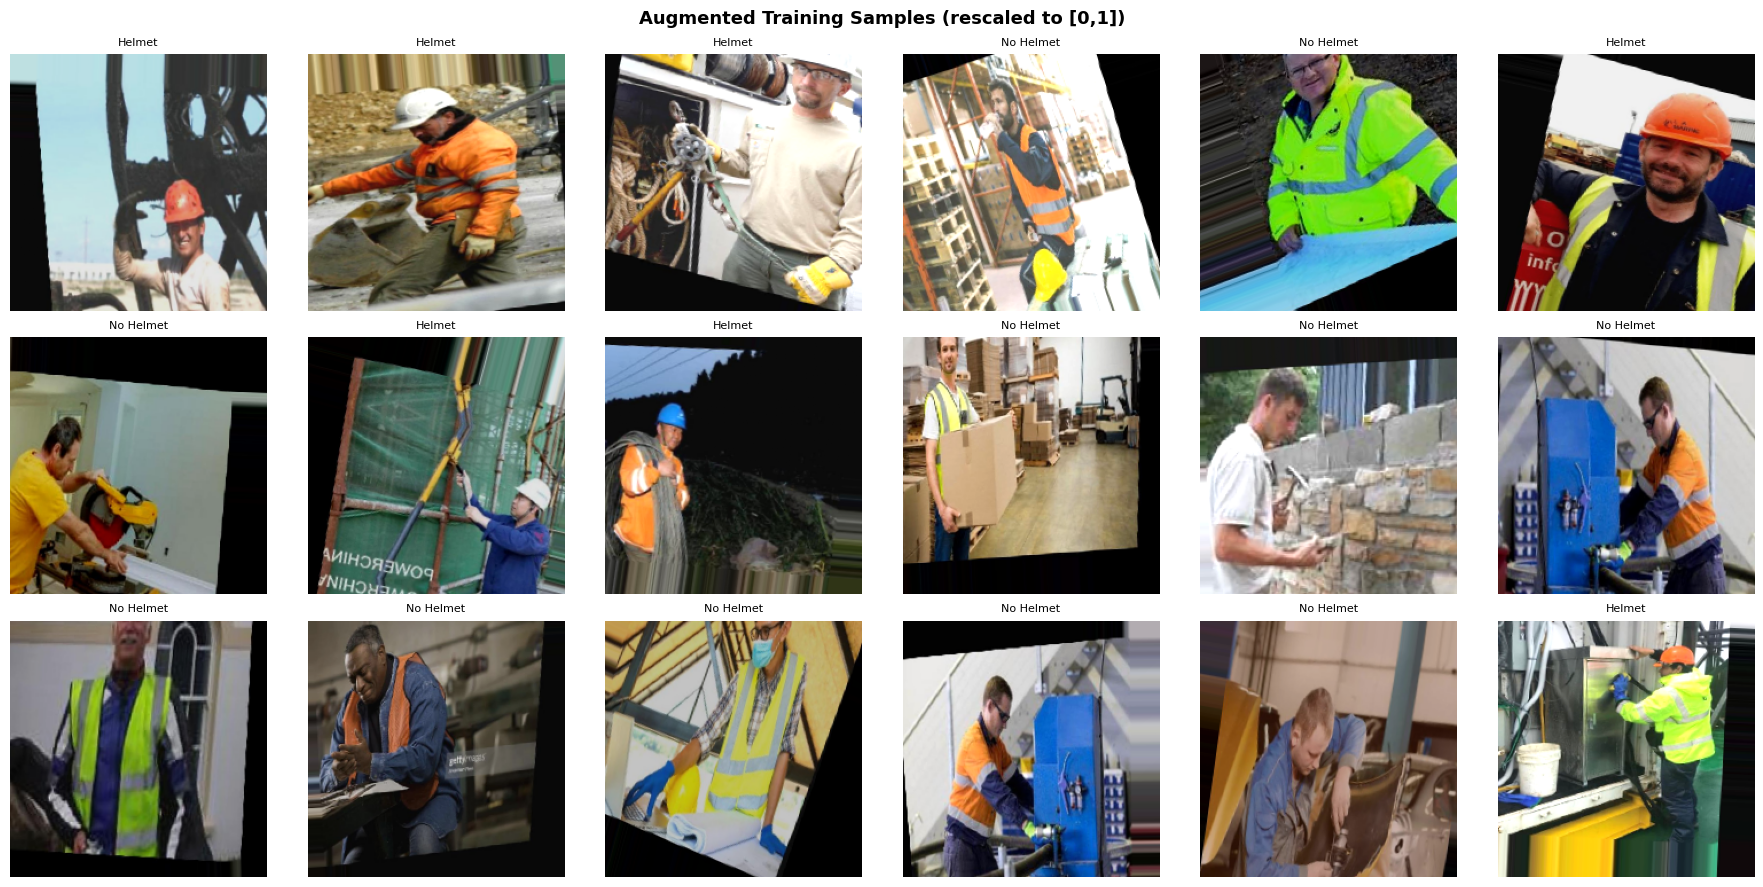

Saved: 03_augmented_samples.pdf


In [19]:
# ── Visualise augmented images ─────────────────────────────────
sample_imgs, sample_labels = next(train_gen)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Augmented Training Samples (rescaled to [0,1])', fontsize=13, fontweight='bold')

label_names = {v: k for k, v in train_gen.class_indices.items()}

for i, ax in enumerate(axes.flat):
    if i >= len(sample_imgs): break
    ax.imshow(np.clip(sample_imgs[i], 0, 1))
    lbl = int(sample_labels[i]) if NUM_CLASSES == 2 else np.argmax(sample_labels[i])
    ax.set_title(label_names[lbl], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_augmented_samples.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_augmented_samples.pdf")


## 5. Custom CNN Model

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Custom CNN Architecture
# 3 convolutional blocks (Conv → BN → ReLU → MaxPool → Dropout)
# followed by a dense classification head.
# Batch Normalisation stabilises training; Dropout reduces over-fitting.
# ─────────────────────────────────────────────────────────────────────────────
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    # ── Block 1 ────────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2 ────────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3 ────────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # ── Block 4 ────────────────────────────────────────
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # ── Head ───────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)   # replace Flatten → fewer params
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='Custom_CNN')


cnn_model = build_custom_cnn()

loss_fn = 'binary_crossentropy' if NUM_CLASSES == 2 else 'categorical_crossentropy'

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARN_RATE),
    loss=loss_fn,
    metrics=['accuracy']
)

cnn_model.summary()


I0000 00:00:1780866720.967445      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780866720.973559      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 683,809 (2.61 MB)

 Trainable params: 682,401 (2.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 6. Train Custom CNN

In [21]:
# ── Callbacks ─────────────────────────────────────────────────
# EarlyStopping   → halt if val_loss doesn't improve for 7 epochs
# ReduceLROnPlateau → halve learning rate on val_loss plateau
# ModelCheckpoint → save the best weights

cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(MODELS_DIR / 'best_custom_cnn.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Training Custom CNN …")
cnn_history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS_CNN,
    validation_data=valid_gen,
    callbacks=cnn_callbacks,
    verbose=1
)

print("\nCustom CNN training complete.")


Training Custom CNN …
Epoch 1/30


I0000 00:00:1780866734.495824     245 service.cc:152] XLA service 0x7e77481105f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780866734.495886     245 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780866734.495893     245 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780866735.667439     245 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-07 21:12:21.574218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:12:21.728749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:12:24.704891: E external/local_xl

32/64 ━━━━━━━━━━━━━━━━━━━━ 18s 563ms/step - accuracy: 0.5475 - loss: 0.8125

2026-06-07 21:12:57.343682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:12:57.490214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:12:57.750641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:12:57.893085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:12:58.681049: E external/local_xla/xla/stream_

64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 885ms/step - accuracy: 0.5490 - loss: 0.7367 - val_accuracy: 0.5095 - val_loss: 0.8145 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 528ms/step - accuracy: 0.5975 - loss: 0.6836 - val_accuracy: 0.5095 - val_loss: 0.8590 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 530ms/step - accuracy: 0.5856 - loss: 0.6802 - val_accuracy: 0.5095 - val_loss: 0.7464 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.6114 - loss: 0.6659 - val_accuracy: 0.5095 - val_loss: 0.8304 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 520ms/step - accuracy: 0.6262 - loss: 0.6439 - val_accuracy: 0.4957 - val_loss: 0.7119 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 533ms/step - accuracy: 0.6129 - loss: 0.6569 - val_accuracy: 0.5269 - val_loss: 0.7779 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.6401 - loss: 0.6357 - val_

In [ ]:

# ── Helper: plot accuracy & loss curves ───────────────────────
def plot_history(history, model_name, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} – Training Curves', fontsize=13, fontweight='bold')

    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epochs, history.history['accuracy'],     label='Train Acc',  color='steelblue')
    ax1.plot(epochs, history.history['val_accuracy'], label='Val Acc',    color='darkorange', linestyle='--')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(epochs, history.history['loss'],     label='Train Loss', color='steelblue')
    ax2.plot(epochs, history.history['val_loss'], label='Val Loss',   color='darkorange', linestyle='--')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")


plot_history(cnn_history, 'Custom CNN', '04_cnn_training_curves.pdf')


## 7. Transfer Learning – MobileNetV2

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MobileNetV2 pre-trained on ImageNet.
# Strategy:
#   Phase 1 → Freeze the base, train only the head (feature extraction)
#   Phase 2 → Unfreeze top layers, fine-tune with a low learning rate
# ─────────────────────────────────────────────────────────────────────────────
def build_transfer_model(base_model_cls, model_name, input_shape=(IMG_SIZE, IMG_SIZE, 3),
                          num_classes=NUM_CLASSES):
    base = base_model_cls(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False   # Phase 1: frozen base

    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(128, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)

    if num_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid')(x)
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name=model_name)
    return model, base


# ── MobileNetV2 ───────────────────────────────────────────────
mob_model, mob_base = build_transfer_model(MobileNetV2, 'MobileNetV2')

mob_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARN_RATE),
    loss=loss_fn,
    metrics=['accuracy']
)

mob_callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print("Phase 1 – MobileNetV2 feature extraction …")
mob_history1 = mob_model.fit(
    train_gen, epochs=10,
    validation_data=valid_gen,
    callbacks=mob_callbacks_phase1, verbose=1
)


In [ ]:
# ── Phase 2: Fine-tune top 30 layers of MobileNetV2 ───────────
mob_base.trainable = True
fine_tune_at = len(mob_base.layers) - 30

for layer in mob_base.layers[:fine_tune_at]:
    layer.trainable = False

mob_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # lower LR for fine-tuning
    loss=loss_fn,
    metrics=['accuracy']
)

mob_callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(str(MODELS_DIR / 'best_mobilenetv2.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Phase 2 – MobileNetV2 fine-tuning …")
mob_history2 = mob_model.fit(
    train_gen, epochs=EPOCHS_TL,
    validation_data=valid_gen,
    callbacks=mob_callbacks_phase2, verbose=1
)

# Merge phase-1 + phase-2 histories for plotting
def merge_histories(h1, h2):
    merged = {k: h1.history[k] + h2.history[k] for k in h1.history}
    class FakeHistory:
        def __init__(self, d): self.history = d
    return FakeHistory(merged)

mob_history = merge_histories(mob_history1, mob_history2)
plot_history(mob_history, 'MobileNetV2', '05_mobilenetv2_training_curves.pdf')


## 8. Transfer Learning – ResNet50

In [ ]:
# ResNet50 pre-trained on ImageNet.
# ResNet50 uses residual (skip) connections which help gradient flow during training.
# Strategy: same 2-phase approach — freeze base first, then fine-tune top layers.
# Note: ResNet50 expects inputs preprocessed with tf.keras.applications.resnet.preprocess_input,
#       but since we already normalised to [0,1] we use the same pipeline for consistency.
res_model, res_base = build_transfer_model(ResNet50, 'ResNet50')

res_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARN_RATE),
    loss=loss_fn, metrics=['accuracy']
)

res_callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print("Phase 1 – ResNet50 feature extraction …")
res_history1 = res_model.fit(
    train_gen, epochs=10,
    validation_data=valid_gen,
    callbacks=res_callbacks_phase1, verbose=1
)

# ── Phase 2: Fine-tune top 30 layers of ResNet50 ──────────────
res_base.trainable = True
for layer in res_base.layers[:-30]:
    layer.trainable = False

res_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn, metrics=['accuracy']
)

res_callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(str(MODELS_DIR / 'best_resnet50.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("Phase 2 – ResNet50 fine-tuning …")
res_history2 = res_model.fit(
    train_gen, epochs=EPOCHS_TL,
    validation_data=valid_gen,
    callbacks=res_callbacks_phase2, verbose=1
)

res_history = merge_histories(res_history1, res_history2)
plot_history(res_history, 'ResNet50', '06_resnet50_training_curves.pdf')


## 9. Model Evaluation

In [ ]:
# ── Helper: evaluate any model on the test set ────────────────
def evaluate_model(model, generator, model_name):
    """Returns (loss, accuracy, y_true, y_pred_prob, y_pred)."""
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"\n{'─'*45}")
    print(f"Model  : {model_name}")
    print(f"Test Loss     : {loss:.4f}")
    print(f"Test Accuracy : {acc*100:.2f}%")

    # Collect predictions
    generator.reset()
    y_pred_prob = model.predict(generator, verbose=0)
    y_true = generator.classes

    if NUM_CLASSES == 2:
        y_pred_prob_flat = y_pred_prob.ravel()
        y_pred = (y_pred_prob_flat > 0.5).astype(int)
    else:
        y_pred_prob_flat = y_pred_prob
        y_pred = np.argmax(y_pred_prob, axis=1)

    return loss, acc, y_true, y_pred_prob_flat, y_pred


cnn_loss, cnn_acc, cnn_true, cnn_prob, cnn_pred   = evaluate_model(cnn_model,  test_gen, 'Custom CNN')
mob_loss, mob_acc, mob_true, mob_prob, mob_pred   = evaluate_model(mob_model,  test_gen, 'MobileNetV2')
res_loss, res_acc, res_true, res_prob, res_pred   = evaluate_model(res_model,  test_gen, 'ResNet50')


In [ ]:
# ── Classification reports ─────────────────────────────────────
def print_report(y_true, y_pred, model_name):
    print(f"\n{'═'*50}")
    print(f" Classification Report – {model_name}")
    print('═'*50)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


print_report(cnn_true, cnn_pred, 'Custom CNN')
print_report(mob_true, mob_pred, 'MobileNetV2')
print_report(res_true, res_pred, 'ResNet50')


In [ ]:
# ── Confusion matrices (side-by-side) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold')

models_info = [
    ('Custom CNN',  cnn_true,  cnn_pred),
    ('MobileNetV2', mob_true,  mob_pred),
    ('ResNet50',    res_true,  res_pred),
]

for ax, (name, y_true, y_pred) in zip(axes, models_info):
    cm_val = confusion_matrix(y_true, y_pred)
    disp   = ConfusionMatrixDisplay(cm_val, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_confusion_matrices.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_confusion_matrices.pdf")


In [ ]:
# ── ROC Curves ────────────────────────────────────────────────
# (Binary classification: one ROC curve per model)
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('ROC Curves – Test Set', fontsize=13, fontweight='bold')

roc_models = [
    ('Custom CNN',  cnn_true, cnn_prob, 'steelblue'),
    ('MobileNetV2', mob_true, mob_prob, 'darkorange'),
    ('ResNet50',    res_true, res_prob, 'green'),
]

for name, y_true, y_score, color in roc_models:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc      = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_roc_curves.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_roc_curves.pdf")


## 10. Model Comparison Table

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

def model_metrics(y_true, y_pred, y_prob, loss):
    return {
        'Test Acc (%)': round(np.mean(y_true == y_pred) * 100, 2),
        'Precision':    round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':       round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score':     round(f1_score(y_true, y_pred, average='weighted'), 4),
        'ROC-AUC':      round(roc_auc_score(y_true, y_prob), 4),
        'Test Loss':    round(loss, 4),
    }

comparison = {
    'Custom CNN':  model_metrics(cnn_true, cnn_pred, cnn_prob, cnn_loss),
    'MobileNetV2': model_metrics(mob_true, mob_pred, mob_prob, mob_loss),
    'ResNet50':    model_metrics(res_true, res_pred, res_prob, res_loss),
}

df_comparison = pd.DataFrame(comparison).T
print("\n" + "="*70)
print(" MODEL COMPARISON TABLE")
print("="*70)
print(df_comparison.to_string())
print("="*70)

# Save as CSV
df_comparison.to_csv(FIGURES_DIR / 'model_comparison.csv')
print("\nSaved: model_comparison.csv")

# ── Visual comparison bar chart ────────────────────────────────
metrics_to_plot = ['Test Acc (%)', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, metrics_to_plot):
    vals   = df_comparison[metric]
    bars   = ax.bar(vals.index, vals.values,
                    color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
    ax.set_title(metric); ax.set_ylim(0, max(vals.values) * 1.15)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_model_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_model_comparison.pdf")


## 11. Grad-CAM Visualisation

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Grad-CAM highlights which image regions most influenced the model's prediction.
# We pick the last convolutional layer, compute the gradient of the class score
# w.r.t. that layer's activations, and overlay a heatmap on the original image.
# ─────────────────────────────────────────────────────────────────────────────

def get_last_conv_layer(model):
    """Find the name of the last Conv2D layer in the model."""
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Compute Grad-CAM heatmap for a single image (shape: 1, H, W, 3)."""
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index  = 0   # binary: single output neuron
        class_channel = predictions[:, pred_index]

    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_array, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image."""
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], (img_array.shape[1], img_array.shape[2]))
    ).squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[..., :3]
    img_orig        = img_array[0]  # shape (H, W, 3)
    overlay         = heatmap_colored * alpha + img_orig * (1 - alpha)
    return np.clip(overlay, 0, 1)


# Pick 8 test images for Grad-CAM
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
n_gradcam = min(8, len(batch_imgs))

last_conv = get_last_conv_layer(cnn_model)
print(f"Using last Conv2D layer: {last_conv}")

fig, axes = plt.subplots(2, n_gradcam, figsize=(n_gradcam * 3, 7))
fig.suptitle('Grad-CAM – Custom CNN (top: original | bottom: heatmap overlay)',
             fontsize=12, fontweight='bold')

for i in range(n_gradcam):
    img = batch_imgs[i:i+1]   # shape (1, H, W, 3)
    hm  = make_gradcam_heatmap(img, cnn_model, last_conv)
    ov  = overlay_gradcam(img, hm)

    true_lbl = int(batch_labels[i]) if NUM_CLASSES == 2 else np.argmax(batch_labels[i])
    pred_prob = cnn_model.predict(img, verbose=0)[0][0]
    pred_lbl  = int(pred_prob > 0.5)
    color     = 'green' if pred_lbl == true_lbl else 'red'

    axes[0, i].imshow(np.clip(img[0], 0, 1))
    axes[0, i].set_title(f"GT: {CLASS_NAMES[true_lbl]}", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(ov)
    axes[1, i].set_title(f"Pred: {CLASS_NAMES[pred_lbl]}", fontsize=8, color=color)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_gradcam.pdf")


## 12. Error Analysis

In [ ]:
# ── Show mis-classified images ─────────────────────────────────
# We display up to 12 errors: the raw image, its true label, and model's prediction.

def show_errors(model, generator, model_name, save_name, n_show=12):
    generator.reset()
    y_prob  = model.predict(generator, verbose=0).ravel()
    y_pred  = (y_prob > 0.5).astype(int)
    y_true  = generator.classes
    filepaths = generator.filepaths

    wrong_idx = np.where(y_pred != y_true)[0]
    print(f"{model_name} – mis-classified: {len(wrong_idx)} / {len(y_true)}")

    n_show = min(n_show, len(wrong_idx))
    if n_show == 0:
        print("No errors to display!")
        return

    selected = wrong_idx[:n_show]
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    fig.suptitle(f'Error Analysis – {model_name}', fontsize=13, fontweight='bold')
    axes = axes.flat

    for ax, idx in zip(axes, selected):
        img = plt.imread(filepaths[idx])
        ax.imshow(img)
        conf = y_prob[idx] if y_pred[idx] == 1 else 1 - y_prob[idx]
        ax.set_title(
            f"GT: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]} ({conf:.2f})",
            fontsize=8, color='red'
        )
        ax.axis('off')

    for ax in axes:  # hide unused subplots
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}")


show_errors(cnn_model, test_gen, 'Custom CNN',  '11_errors_cnn.pdf')
show_errors(mob_model, test_gen, 'MobileNetV2', '12_errors_mobilenetv2.pdf')
show_errors(res_model, test_gen, 'ResNet50',    '13_errors_resnet50.pdf')


## 13. Save Models

In [ ]:
# Save all three models in Keras native format
cnn_model.save(str(MODELS_DIR / 'custom_cnn_final.keras'))
mob_model.save(str(MODELS_DIR / 'mobilenetv2_final.keras'))
res_model.save(str(MODELS_DIR / 'resnet50_final.keras'))

print("All models saved to:", MODELS_DIR)
print("All figures saved to:", FIGURES_DIR)
print("\nFiles in figures/:", sorted(os.listdir(FIGURES_DIR)))
